### loading the cifar10 dataset

In [3]:
import keras
from keras.datasets import cifar10

# load the pre-shuffled train and test data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


[9]


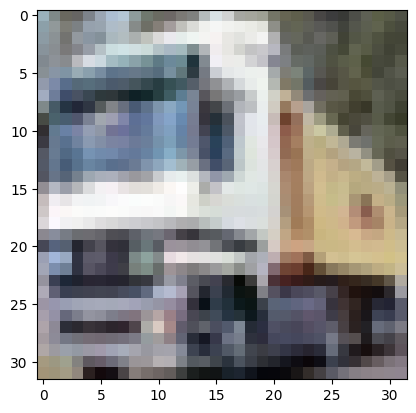

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1])
print(y_train[1])

### Visualize the First 10 Training Images

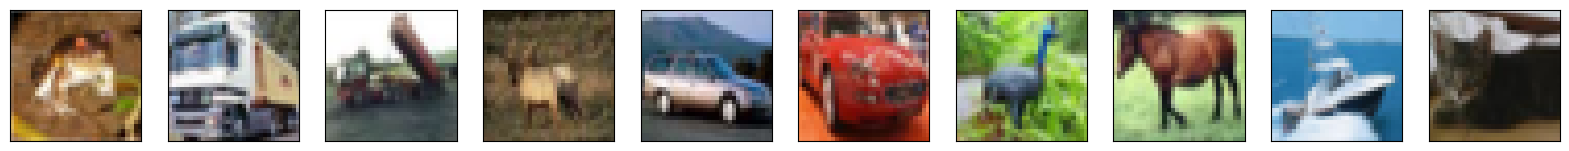

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(10):
    ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i])

### Rescale the Images by Dividing Every Pixel in Every Image by 255

In [6]:
x_train.min()

np.uint8(0)

In [7]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

### Break Dataset into Training, Testing, and Validation Sets

In [8]:
from tensorflow.keras.utils import to_categorical
from tensorflow import keras


# break training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# print shape of training set
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

print('x_valid shape:', x_valid.shape)
print('x_valid shape:', y_valid.shape)


# print number of training, validation, and test images
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_valid.shape[0], 'validation samples')

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
x_valid shape: (5000, 32, 32, 3)
x_valid shape: (5000, 1)
45000 train samples
10000 test samples
5000 validation samples


### Define the Model Architecture

In [9]:
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]


In [10]:
x_train.shape

(40000, 32, 32, 3)

In [11]:
x_valid.shape

(5000, 32, 32, 3)

In [12]:
y_train.shape

(40000, 1)

In [13]:
x_test.shape

(10000, 32, 32, 3)

In [14]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu',
                        input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,094 (2.06 MB)

 Trainable params: 541,094 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

In [15]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### Train the Model

In [16]:
from keras.callbacks import ModelCheckpoint

# train the model
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

hist = model.fit(x_train, y_train, batch_size=32, epochs=30,
          validation_data=(x_valid, y_valid), callbacks=[checkpointer],
          verbose=2, shuffle=True)

Epoch 1/30

Epoch 1: val_loss improved from inf to 1.26472, saving model to model.weights.best.keras
1250/1250 - 15s - 12ms/step - accuracy: 0.4086 - loss: 1.6150 - val_accuracy: 0.5462 - val_loss: 1.2647
Epoch 2/30

Epoch 2: val_loss improved from 1.26472 to 1.11523, saving model to model.weights.best.keras
1250/1250 - 6s - 4ms/step - accuracy: 0.5313 - loss: 1.3070 - val_accuracy: 0.5992 - val_loss: 1.1152
Epoch 3/30

Epoch 3: val_loss improved from 1.11523 to 1.05331, saving model to model.weights.best.keras
1250/1250 - 9s - 8ms/step - accuracy: 0.5727 - loss: 1.1899 - val_accuracy: 0.6188 - val_loss: 1.0533
Epoch 4/30

Epoch 4: val_loss improved from 1.05331 to 1.02203, saving model to model.weights.best.keras
1250/1250 - 4s - 4ms/step - accuracy: 0.6061 - loss: 1.1066 - val_accuracy: 0.6366 - val_loss: 1.0220
Epoch 5/30

Epoch 5: val_loss improved from 1.02203 to 0.93270, saving model to model.weights.best.keras
1250/1250 - 4s - 3ms/step - accuracy: 0.6318 - loss: 1.0415 - val_acc

### 8. Load the Model with the Best Validation Accuracy

In [17]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [18]:
model.load_weights('model.weights.best.keras')

### 9. Visualize Some Predictions

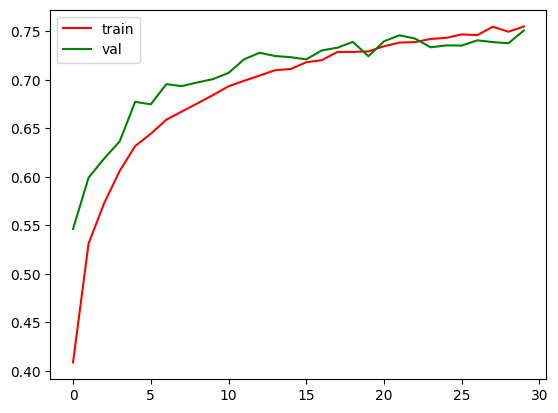

In [19]:
plt.plot(hist.history["accuracy"],color='red',label="train")
plt.plot(hist.history["val_accuracy"],color="green",label='val')
plt.legend()

In [20]:
model.evaluate(x_test,y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7573 - loss: 0.7376


[0.7365350723266602, 0.7569000124931335]